In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as scsp
import scipy.interpolate as scpo
from IPython.display import display, Math
plt.style.use('seaborn-v0_8-darkgrid')

## Introduction

Let $X \sim \mathrm{LogN}(\mu, v)$ be a lognormally distributed random variable, so that $\ln X \sim \mathcal{N}(\mu, v)$, where $\mu$ and $v$ denote the mean and variance of $\ln X$, respectively, and $\mathcal{N}$ denotes the normal distribution. Our aim is to represent the following Laplace transform as the limit of a sequence of explicitly computable closed-form expressions
$$\mathcal{L}_X(u) = \mathrm{E}\!\left[e^{-uX}\right] = \int_0^\infty f_X(x)\, e^{-u\cdot x}\,dx.$$

Since $X = e^\mu X_0$ in distribution, where $X_0 \sim \mathrm{LogN}(0,v)$, we have $\mathcal{L}_X(u) = \mathcal{L}_{X_0}(e^\mu u)$, so it suffices to treat the case $\mu = 0$. Henceforth we write $\mathcal{L}(u) := \mathcal{L}_{X_0}(u)$, with density
$$f_X(x) = \frac{1}{x\sqrt{2\pi v}}\,e^{-\ln^2(x)/2v}.$$

We introduce the one-parameter family of functions
$$f_\ell(x,v) = \frac{1}{x^\ell \sqrt{2\pi v}}\,e^{-\ln^2(x)/2v}, \qquad \ell \in \mathbb{R},$$
so that in particular $f_1(x,v) = f_X(x)$. The case $\ell = 0$ gives
$$f_0(x,v) = \frac{1}{\sqrt{2\pi v}}\,e^{-\ln^2(x)/2v},$$
which satisfies the reflection symmetry $f_0(x,v) = f_0(1/x,\,v)$, since $\ln(1/x) = -\ln x$. We note the identity
$$t^{\ell-1} f_\ell(x,v) = f_1(x,v), \quad \text{for all } \ell,$$
which will simplify subsequent manipulations.

We split the Laplace transform at $x=1$. Writing $f_1 = f_0/x$, we have
$$\mathcal{L}_v(u) = \int_0^1 f_1(x,v)\,e^{-u\cdot x}\,dx + \int_1^\infty \frac{f_0(x,v)}{x}\,e^{-u\cdot x}\,dx.$$

In the second integral we apply the substitution $t = 1/x$, so that $dx = -dt/t^2$. Using the symmetry $f_0(1/t,\,v) = f_0(t,v)$:
$$\int_1^\infty \frac{f_0(x,v)}{x}\,e^{-u\cdot x}\,dx = \int_0^1 \frac{f_0(t,v)}{t}\,e^{-u/t}\,dt = \int_0^1 f_1(t,v)\,e^{-u/t}\,dt.$$

Renaming $t$ as $x$ in the second integral and combining, we obtain
$$\mathcal{L}_v(u) = \int_0^1 \bigl(e^{-u\cdot x} + e^{-u/x}\bigr)\, f_1(x,v)\,dt = \int_0^1 \bigl(e^{-u\cdot x} + e^{-u/x}\bigr)\, x^{\ell-1} f_\ell(x,v)\,dx,$$
where the second equality uses the identity $x^{\ell-1}f_\ell = f_1$, and $\ell$ is a free parameter to be chosen below.

The strategy is to approximate $f_\ell(x,v)$ on $[0,1]$ as a finite linear combination
$$f_\ell(x,v) \approx \sum_m c_m\, \phi_m(x)$$
of basis functions $\{\phi_m\}$, chosen so that the integrals
$$I_m(u) = \int_0^1 \bigl(e^{-u\cdot x} + e^{-u/x}\bigr)\, x^{\ell-1}\, \phi_m(x)\,dt$$
admit analytical closed forms. We consider the following types of basis:

- **Rational:** $\phi_m(x) = \dfrac{1}{x - p_m}$, $\;p_m \in \mathbb{C}$, with $\ell = 1$.
- **Power:** $\phi_m(x) = x^{p_m}$, with $\ell = 0$, in two variants:
  - $p_m \in \mathbb{R}$,
  - $p_m \in \mathbb{C}$.

### Behaviour of the approximation at the origin

Note that $\mathcal{L}(0) = 1$. For a high-quality approximation, the sum
$$S_0 = \sum_m c_m\, I_m(0) = 2\sum_m c_m \int_0^1 x^{\ell-1}\phi_m(x)\,dx$$
should be as close to one as possible.

For the rational approximation ($\ell = 1$) this sum is given by
$$S_0 = 2\sum_m c_m \int_0^1 \frac{dx}{x - p_m} = 2\sum_m c_m \ln\!\left(1 - \frac{1}{p_m}\right).$$
For the power approximation ($\ell = 0$) it takes the form
$$S_0 = 2\sum_m c_m \int_0^1 x^{p_m-1}\,dx = 2\sum_m \frac{c_m}{p_m}.$$

In practice, approximation algorithms do not in general yield $S_0 = 1$ exactly. To compensate, the parameter-fitting routines accept a boolean flag $\texttt{do\_zero\_correction}$: when set to $\texttt{True}$ (the default), the coefficients $c_m$ are divided by the computed value of $S_0$, after which $S_0 = 1$ holds identically.

## Key properties of the functions $f_\ell$

We briefly survey the main properties of the functions with which we shall work, and the difficulties they present. We first rewrite
$$f_\ell(x,v) = \frac{1}{x^\ell \sqrt{2\pi v}}\,\exp\!\left(-\frac{\ln^2 x}{2v}\right) = \frac{1}{\sqrt{2\pi v}}\,\exp\!\left(-\frac{\ln^2 x + 2v\ell\ln x}{2v}\right)$$
$$= \frac{1}{\sqrt{2\pi v}}\,\exp\!\left(\frac{v\ell^2}{2} - \frac{(\ln x + v\ell)^2}{2v}\right) = \frac{e^{v\ell^2/2}}{\sqrt{2\pi v}}\,\exp\!\left(-\frac{\ln^2(e^{v\ell}x)}{2v}\right),$$
and, recalling that $v = \sigma^2$, arrive at the final form
$$f_\ell(x,v) = \frac{e^{v\ell^2/2}}{\sqrt{2\pi v}}\,\exp\!\left(-\frac{\ln^2\!\left(e^{\sigma\ell}\, x^{1/\sigma}\right)}{2}\right) = \frac{e^{v\ell^2/2}}{\sqrt{v}}\,f_0\!\left(e^{\sigma\ell}\, x^{1/\sigma},\, 1\right).$$
Thus every $f_\ell(x,v)$ is obtained from $f_0(t,1)$ by the substitution $t = e^{\sigma\ell}\, x^{1/\sigma}$ (equivalently, $x = e^{-v\ell}\, t^{\sigma}$) and multiplication by the scaling factor $e^{v\ell^2/2}/\sqrt{v}$.

Plots of $f_\ell(x,v)$:


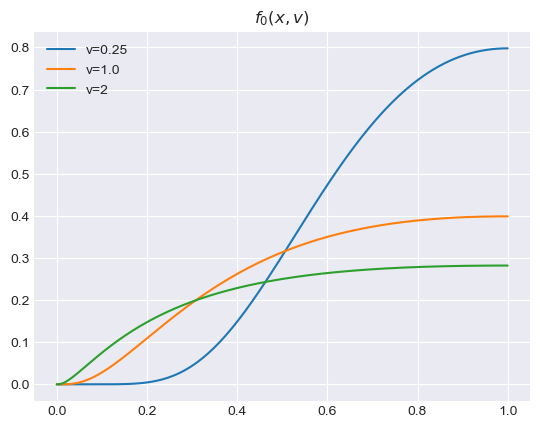

In [3]:
def f_ell(x,v=1.,l=0):
    v=np.atleast_1d(v)[:,None]
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(x == 0,0.0,np.exp(v*l**2 -(np.log(x) + v*l)**2 / (2 * v))/np.sqrt(2.*np.pi*v)).T

x=np.linspace(0.,1.,257)
v=(0.25,1.,2)
plt.title('$f_0(x,v)$')
plt.plot(x,f_ell(x,v),label=['v=' + str(vi) for vi in v])
plt.legend()
plt.show()

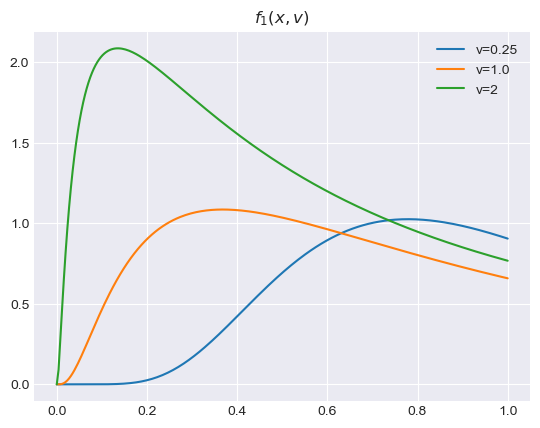

In [4]:
plt.title('$f_1(x,v)$')
plt.plot(x,f_ell(x,v,1),label=['v=' + str(vi) for vi in v])
plt.legend()
plt.show()

The functions $f_\ell$ are infinitely differentiable on $[0,1]$ and exhibit a characteristic behaviour at the origin: all derivatives of every order vanish at $x = 0$, the Taylor series is identically zero, and hence does not converge to the function. Any power-series expansion about an interior point of $[0,1]$ has a radius of convergence that excludes the origin.

At the same time, the origin receives the greatest weight from the factor $e^{-ux}$ — the first term in $e^{-ux} + e^{-u/x}$. Both terms are shown below.

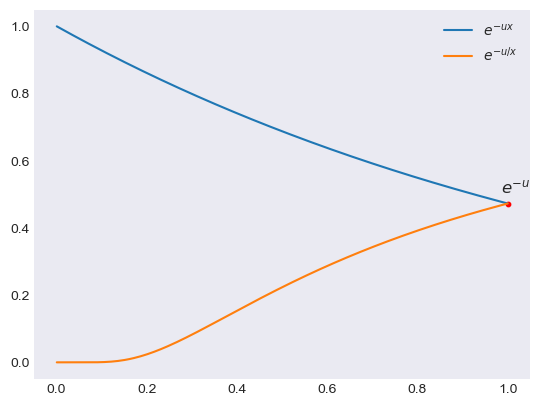

In [5]:
u = 0.75
x = np.linspace(1e-3, 1, 200)       # избегаем деления на 0 вблизи x=0
plt.plot(x, np.exp(-u * x), label=r'$e^{-u x}$')
plt.plot(x, np.exp(-u / x), label=r'$e^{-u / x}$')
plt.scatter(1, np.exp(-u), color='red',s=10)  # общая точка (1, e^{-u})
plt.annotate(r'$e^{-u}$', (0.96, np.exp(-u)),
             textcoords="offset points", xytext=(8, 8), fontsize=12)
plt.legend()
plt.grid()
plt.show()

The first term is monotonically decreasing, the second is monotonically increasing; they meet at the right endpoint $x = 1$ with the common value $e^{-u}$. Like $f_\ell$, the second term $e^{-u/x}$ also has all its derivatives vanishing at the origin.

The sum $e^{-ux} + e^{-u/x}$ is shown below.

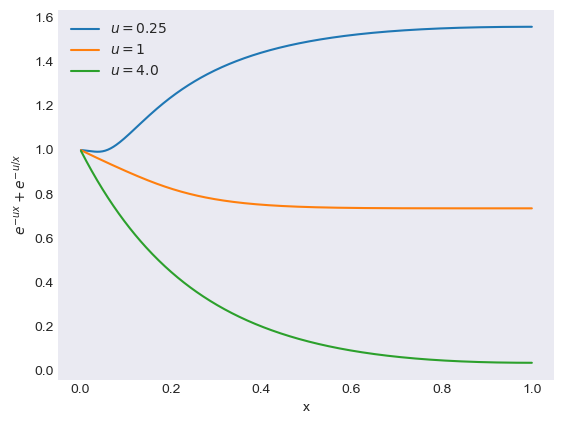

In [6]:
u_values = [0.25, 1, 4.0]
x = np.linspace(1e-3, 1, 500)       # избегаем деления на 0 вблизи x=0

for u in u_values:
    y = np.exp(-u * x) + np.exp(-u / x)
    plt.plot(x, y, label=rf'$u = {u}$')

plt.xlabel('x')
plt.ylabel(r'$e^{-u x} + e^{-u / x}$')
plt.legend()
plt.grid()
plt.show()

## Rational approximation: the AAA algorithm

To obtain a rational approximation to $f_1(x)$ we employ the AAA algorithm, which is conveniently available in the $\texttt{scipy}$ package.

The AAA algorithm approximates a function, given by its values on a discrete grid, by a rational function. We choose a grid on $[0,1]$, evaluate $f_1(x)$ on it, and convert from the barycentric representation to the pole--residue form, obtaining
$$f_1(x) \approx \sum_{m=1}^n \frac{r_m}{x - z_m},$$
where $r_m$ are the residues and $z_m$ the poles. The algorithm guarantees that all poles lie outside the approximation interval $[0,1]$; they are either real or occur in complex-conjugate pairs.

Substituting a single term into the integral of interest gives
$$I_m = \int_0^1 \frac{e^{-ux}+e^{-u/x}}{x - z_m}\,dx = I_{m,1} + I_{m,2},$$
where
$$I_{m,1} = \int_0^1 \frac{e^{-ux}}{x - z_m}\,dx, \qquad I_{m,2} = \int_0^1 \frac{e^{-u/x}}{x - z_m}\,dx.$$

**Evaluation of $I_{m,1}$.** The substitution $t = x - z_m$ gives
$$\int_{-z_m}^{1-z_m} \frac{e^{-u(t+z_m)}}{t}\,dt = e^{-uz_m} \int_{-z_m}^{1-z_m} \frac{e^{-ut}}{t}\,dt.$$
A further substitution $w = -ut$ then yields
$$I_{m,1} = e^{-uz_m} \int_{uz_m}^{u(z_m-1)} \frac{e^{w}}{w}\,dw = e^{-uz_m}\bigl[\mathrm{Ei}(uz_m - u) - \mathrm{Ei}(uz_m)\bigr].$$

**Evaluation of $I_{m,2}$.** The substitution $x = 1/t$ transforms the integral to
$$\int_1^\infty \frac{e^{-ut}}{t(1 - z_m t)}\,dt.$$
A partial-fraction decomposition gives
$$\frac{1}{t(1 - z_m t)} = \frac{1}{t} - \frac{1}{t - 1/z_m},$$
so
$$I_{m,2} = \int_1^\infty \frac{e^{-ut}}{t}\,dt - \int_1^\infty \frac{e^{-ut}}{t - 1/z_m}\,dt.$$
The first integral is the exponential integral $E_1(u)$. For the second, the substitution $w = u(t - 1/z_m)$ gives
$$\int_1^\infty \frac{e^{-ut}}{t - 1/z_m}\,dt = e^{-u/z_m}\, E_1\!\left(u - \frac{u}{z_m}\right),$$
and therefore
$$I_{m,2} = E_1(u) - e^{-u/z_m}\, E_1\!\left(u - \frac{u}{z_m}\right).$$

Combining $I_{m,1}$ and $I_{m,2}$, the rational approximation to the Laplace transform reads
$\mathcal{L}(u) \approx \sum_{m=1}^n c_m I_m ,$ where
$$ I_m=e^{-uz_m}\bigl(\mathrm{Ei}(uz_m - u) - \mathrm{Ei}(uz_m)\bigr) + E_1(u) - e^{-u/z_m}\, E_1\!\left(u - \frac{u}{z_m}\right).$$



Due to numerical instability at large arguments, we do not use the derived formula
directly. We first rewrite it in a form involving only $E_1$, using the identity
$\mathrm{Ei}(z) = -E_1(-z)$:
$$I_m = E_1(u) + e^{-u z_m}\!\left[E_1(-u z_m) - E_1\!\left(u(1-z_m)\right)\right]
- e^{-u/z_m} E_1\!\left(u - \frac{u}{z_m}\right).$$

We then eliminate $E_1$ entirely in favour of the confluent hypergeometric function
$U(1,1,z)$, which satisfies $U(1,1,z) = e^z E_1(z)$ and which we abbreviate as
$U_{11}(z)$. Substituting $E_1(z) = e^{-z}U_{11}(z)$ throughout and simplifying gives
$$I_m = U_{11}(-u z_m)
+ e^{-u}\!\left[U_{11}(u) - U_{11}\!\left(-u(z_m-1)\right)
- U_{11}\!\left(u - \frac{u}{z_m}\right)\right].$$

The implementation of $U_{11}$ is given below. For moderate arguments it is evaluated
directly as $e^z E_1(z)$; for large arguments ($|z| > 500$) the exponential would
overflow, so we switch to the asymptotic expansion
$$U_{11}(z) \sim z^{-1}\sum_{k=0}^{7}(-1)^k \frac{k!}{z^{k}}, \qquad |z|\to\infty,$$
which achieves accuracy of order $10^{-18}$ for $|z|>500$.

In [7]:
def U11(z):
    """
    Numerically stable implementation of U(1,1,z) = exp(z) * E_1(z).

    Supports complex arguments throughout. For |z| < 500 the function is
    evaluated directly; for larger arguments an 8-term asymptotic expansion
    is used to avoid overflow.

    Note: scipy.special.hyperu(1,1,z) is not used here because it does not
    support complex arguments.
    """
    z = np.asarray(z, dtype=complex)
    res = np.zeros_like(z, dtype=complex)

    # Direct evaluation in the safe region
    normal_mask = np.abs(z) < 500.0
    if np.any(normal_mask):
        z_norm = z[normal_mask]
        res[normal_mask] = np.exp(z_norm) * scsp.exp1(z_norm)

    # Asymptotic expansion for large |z| to avoid overflow
    big_mask = ~normal_mask
    if np.any(big_mask):
        inv_z = 1.0 / z[big_mask]

        # 8-term series: U11(z) ~ (1/z) * sum_{k=0}^{7} (-1)^k k! / z^k
        # Accuracy ~ 1e-18 for |z| > 500
        coefficients = [-1.0, 2.0, -6.0, 24.0, -120.0, 720.0, -5040.0]
        series_sum = np.ones_like(inv_z, dtype=complex)   # k=0 term
        current_inv_z = np.copy(inv_z)

        for coef in coefficients:                          # k=1,...,7 terms
            series_sum += coef * current_inv_z
            current_inv_z *= inv_z

        res[big_mask] = inv_z * series_sum

    return res


### Grid selection strategy for the AAA algorithm

Since $f_1(x,v)$ is obtained from $f_0(t,1)$ by a change of variable and a scaling
(as established earlier), and $f_0(t,1)$ is a standard Gaussian in log-space, it is
natural to work with a fixed uniform grid in $\ln t$ and transform it to $x$-space
rather than constructing a new grid for each $v$.

The transformation $x = e^{-v}t^{\sigma}$ becomes linear in logarithms:
$$\ln x = \sigma\ln t - v,$$
so a uniform grid in $\ln t$ maps to a uniform grid in $\ln x$, shifted and scaled by
$v$ and $\sigma$. We choose a fixed log-space range wide enough that, after
transformation, it covers $x$-values from a negligibly small positive number up to $1$
for any reasonable $v$.

In [8]:
def points_for_AAA(v, num_points, first_zero=True):
    """
    Returns (x_train, y_train): num_points evaluation points of f_1(x, v)
    for use as training data in the AAA algorithm.

    The points are generated on a fixed uniform grid in log-space and then
    mapped to x-space via the substitution x = exp(sigma * log_t - v),
    which avoids dense resampling for each new value of v.
    """
    # Fixed uniform grid in log-space (independent of v)
    log_range = np.linspace(-36., 11., num_points)

    # Evaluate f_1(x, v) = exp(v/2) / sqrt(2*pi*v) * exp(-log_t^2 / 2)
    y_train = np.exp(0.5 * (v - log_range**2)) / np.sqrt(2. * v * np.pi)

    # Map log-space grid to x via x = exp(sigma * log_t - v)
    x_train = np.exp(np.sqrt(v) * log_range - v)

    if first_zero: # add zero as first element
        return np.r_[0,x_train],np.r_[0,y_train]
    return x_train, y_train


### Complete implementation of the rational approximation

The function below builds the rational approximation to $f_1(x,v)$ via the AAA
algorithm and returns a callable $\mathcal{L}(u)$ that evaluates the Laplace transform
of the log-normal distribution.

In [9]:
def LT_LN_AAA_real_uF(v, num_points=2000, do_zero_correction=True, first_zero=True, rtol=1e-12):
    """
    Constructs a rational approximation to f_1(x, v) using the AAA algorithm
    and returns a function L(u) that evaluates the Laplace transform of the
    LogN(0, v) distribution.

    Parameters
    ----------
    v             : lognormal variance parameter
    num_points    : number of training points for the AAA algorithm
    do_zero_correction : if True (default), rescale residues so that L(0) = 1 exactly
    rtol          : relative tolerance passed to the AAA algorithm
    """
    # Build the rational approximation using scipy.interpolate.AAA
    approx = scpo.AAA(*points_for_AAA(v, num_points, first_zero), rtol=rtol)
    poles, residues = approx.poles(), approx.residues()

    if do_zero_correction:
        # Normalise so that L(0) = sum_m r_m * I_m(0) = 1
        corr_coef = 2. * np.real(np.dot(residues, np.log(1 - 1 / poles)))
        residues = residues / corr_coef

    def laplace_fn(u):
        """
        Evaluates L(u) = sum_m r_m * I_m(u) using the U11-based formula.
        """
        u = np.asarray(u, dtype=complex)
        total_integral = np.zeros_like(u, dtype=complex)

        for zi, ri in zip(poles, residues):
            w1 = -u * zi
            w2 = u * (zi - 1.0)
            total_integral += ri * (
                U11(w1) + (U11(u) - U11(w2 / zi) - U11(-w2)) * np.exp(-u)
            )

        return np.where(u == 0, 1., np.real(total_integral))

    return laplace_fn


We can now load the required auxiliary functions and benchmark the result against
a reference implementation based on direct numerical integration using
Gauss--Hermite quadrature.

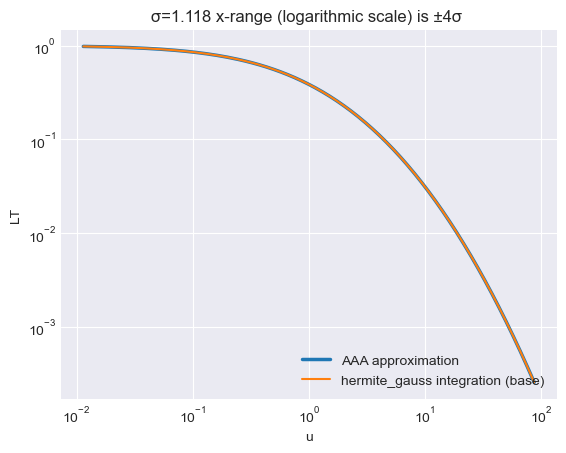

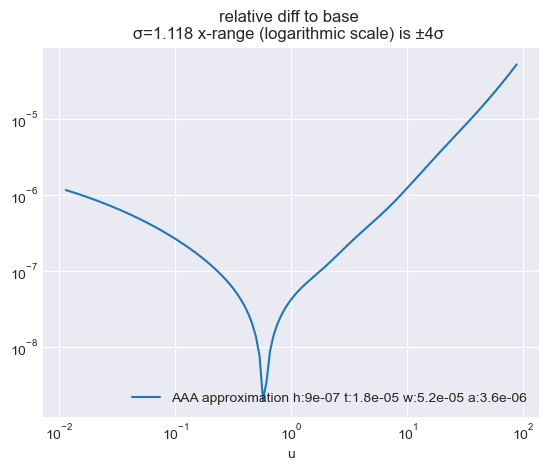

In [10]:
import sys
%run -i LTLN_direct_integration.py
%run -i inverse_LT.py
%run -i laplace_plots.py
v=1.25
methods_list=(
        ('hermite_gauss integration',LTLN_DI_real_uF(v,55)),
        ('AAA approximation',LT_LN_AAA_real_uF(v)),
        )
LT_plot(v,methods_list,spread=4,accuracy_only=False)


## Power series approximation

We now turn to the power series case. Setting $\phi_m(x) = x^{p_m}$ and $\ell = 0$,
we approximate $f_0(x,v)$ as
$$f_0(x,v) \approx \sum_m c_m\, x^{p_m},$$
where $\mathrm{Re}(p_m)>0$ and the exponents $p_m$ are to be chosen later (the
choice will be discussed in the next section).

Since $f_0(x,\sigma^2)$ is obtained from $f_0(t,1)$ by the substitution $x = t^{1/\sigma}$
and multiplication by $1/\sigma$, any approximation
$f_0(t,1)\approx\sum_m c'_m t^{p'_m}$ yields the corresponding approximation for
general $v=\sigma^2$ via the rescaling
$$c_m = c'_m/\sigma,\qquad p_m = p'_m/\sigma.$$
It therefore suffices to construct the approximation for $v=1$ only, and we write
$f_0(x)$ for $f_0(x,1)$ throughout.

**The basis integrals.** With $\ell=0$, the integrals introduced in the Introduction become
$$I_m(u) = \int_0^1 \bigl(e^{-ux}+e^{-u/x}\bigr)\,x^{p_m-1}\,dx.$$
Each of the two exponential terms is handled by a straightforward substitution
($t=ux$ for the first, $t=u/x$ for the second), and one obtains
$$I_m(u) = u^{-p_m}\,\gamma(p_m,\,u)+u^{\,p_m}\,\Gamma(-p_m,\,u),$$
where $\gamma(a,u)=\int_0^u t^{a-1}e^{-t}\,dt$ and
$\Gamma(a,u)=\int_u^\infty t^{a-1}e^{-t}\,dt$ are the lower and upper incomplete
gamma functions. (The upper function is defined for $\mathrm{Re}(a)<0$ by the same
integral, which converges at infinity whenever $u>0$.)

### Real-valued exponents $p_m$

We introduce the weighted inner product
$$\langle f,g\rangle_q = \int_0^1 f(x)\,g(x)\,x^{q-1}\,dx, \qquad q>0,$$
with the associated norm $\|f\|_q^2 = \langle f,f\rangle_q$. The parameter $q$ controls
where the norm concentrates: values $q<1$ emphasise the left end of the interval,
while $q>1$ emphasise the right end.

For a given set of exponents $p_m$, finding the optimal coefficients $c_m$ reduces to
minimising
$$\Bigl\|f_0(x)-\sum_m c_m x^{p_m}\Bigr\|_q^2\;\longrightarrow\;\min.$$
Expanding the squared norm and collecting terms in $c_i c_j$ gives the equivalent form
$$\sum_{i=1}^n\sum_{j=1}^n c_i c_j\,\langle x^{p_i},x^{p_j}\rangle_q
-2\sum_{i=1}^n c_i\,\langle x^{p_i},f_0(x)\rangle_q\;\longrightarrow\;\min.$$

One may additionally impose constraints on the coefficients. Two natural choices are:
the normalisation condition $\mathcal{L}(0)=1$, which takes the form
$2\sum_m c_m/p_m=1$ (see above), and the requirement that the approximation
reproduces the exact value at $x=1$, i.e.\ $\sum_m c_m = f_0(1)$.

Adding Lagrange multipliers $\lambda_1$ and $\lambda_2$ for these two constraints and
differentiating with respect to $c_m$, $\lambda_1$, $\lambda_2$ yields the linear
system
$$
\begin{pmatrix}
\langle x^{p_1},x^{p_1}\rangle_q & \cdots & \langle x^{p_1},x^{p_n}\rangle_q & 2/p_1 & 1\\
\vdots & \ddots & \vdots & \vdots & \vdots\\
\langle x^{p_n},x^{p_1}\rangle_q & \cdots & \langle x^{p_n},x^{p_n}\rangle_q & 2/p_n & 1\\
2/p_1 & \cdots & 2/p_n & 0 & 0\\
1 & \cdots & 1 & 0 & 0
\end{pmatrix}
\begin{pmatrix}c_1\\\vdots\\c_n\\\lambda_1\\\lambda_2\end{pmatrix}
=
\begin{pmatrix}
\langle x^{p_1},f_0(x)\rangle_q\\
\vdots\\
\langle x^{p_n},f_0(x)\rangle_q\\
1\\
f_0(1)
\end{pmatrix}.
$$

#### Schur complement

The unconstrained block of the system above is the $n\times n$ symmetric
positive definite system
$$H\mathbf{c} = \mathbf{f}, \qquad H_{ij}=\langle x^{p_i},x^{p_j}\rangle_q
=\frac{1}{p_i+p_j+q},\quad f_i=\langle x^{p_i},f_0(x)\rangle_q.$$
The matrix $H$ is a generalised Hilbert matrix; it reduces to the classical Hilbert
matrix when $q=1$ and $p_i=i-1$. Although such matrices are severely ill-conditioned,
effective solution strategies exist and will be described in the next section.

Adding constraints destroys positive definiteness and complicates the problem. The
Schur complement technique lets us reduce the constrained system to the unconstrained
one, reusing whatever solver is available for $H$.

Write the full system in block form:
$$
\begin{pmatrix}H & C^T\\C & 0\end{pmatrix}
\begin{pmatrix}\mathbf{c}\\\boldsymbol{\lambda}\end{pmatrix}
=\begin{pmatrix}\mathbf{f}\\\mathbf{d}\end{pmatrix},
$$
where the rows of $C$ encode the constraint coefficients ($C_{1m}=2/p_m$,
$C_{2m}=1$) and $\mathbf{d}=(1,\,f_0(1))^T$. The block equations are
$$H\mathbf{c}+C^T\boldsymbol{\lambda}=\mathbf{f}, \qquad C\mathbf{c}=\mathbf{d}.$$
Solving the first equation for $\mathbf{c}$ and substituting into the second:
$$\mathbf{c}=H^{-1}(\mathbf{f}-C^T\boldsymbol{\lambda}),\qquad
CH^{-1}\mathbf{f}-CH^{-1}C^T\boldsymbol{\lambda}=\mathbf{d}.$$
Rearranging:
$$(CH^{-1}C^T)\boldsymbol{\lambda}=CH^{-1}\mathbf{f}-\mathbf{d}.$$
The matrix $S=CH^{-1}C^T$ is the **Schur complement** of $H$.

In practice one never forms $H^{-1}$ explicitly. Instead:
1. Solve $HX=C^T$ for the $n\times 2$ matrix $X$; then $S=CX$.
2. Solve $H\mathbf{x}=\mathbf{f}$ for the vector $\mathbf{x}$; then
$\mathbf{r}=C\mathbf{x}-\mathbf{d}$.
3. Solve the small $2\times 2$ system $S\boldsymbol{\lambda}=\mathbf{r}$ for
$\boldsymbol{\lambda}$.
4. Recover $\mathbf{c}$ from $H\mathbf{c}=\mathbf{f}-C^T\boldsymbol{\lambda}$.

In [ ]:
def schur_row_C_col_R(solve, C, R, rc):
    '''
    Solve a constrained linear system using a Schur complement reduction.
    
    The method assumes an underlying symmetric positive definite (SPD) system:
        H x = R
    where the linear system is solved indirectly via a provided solver function:
        solve(v) -> H^{-1} v
    Additional linear constraints are imposed:
        C x = rc
    Parameters
    ----------
    solve : callable
        Function that solves the SPD system A x = v, i.e. returns A^{-1} v 
        (v can be a matrix).
    
    C : ndarray, shape (k, n)
        Constraint matrix (each row defines one linear constraint).
        All the constraints are applied to each column of the right-hand side!!
    
    R : ndarray, shape (n,l)
        Right-hand side of the original unconstrained system (each of l columns defines one right-hand side).
    
    rc : ndarray, shape (k,l)
        Right-hand side values for the constraints.
    
    Returns
    -------
    x : ndarray, shape (n,l)
        Solution of the constrained system.
    ''' 
    C = np.asarray(C)
    r = np.asarray(R)
    rc = np.asarray(rc)
    y = solve(r)
    Z = solve(C.T)
    S = C @ Z
    rhs = C @ y - rc
    lam = np.linalg.solve(S, rhs)
    return y - Z @ lam


#### Müntz--Legendre polynomials and inversion of $H$

We now address the solution of $H\mathbf{c}=\mathbf{f}$ for the specific matrix $H$
defined by the exponents $p_1,\ldots,p_n$.

Apply the Gram--Schmidt process to the sequence of monomials $x^{p_1},x^{p_2},\ldots$
with respect to $\langle\cdot,\cdot\rangle_q$, producing an orthogonal basis
$e_1(x),e_2(x),\ldots$ satisfying
$$\langle e_i,e_j\rangle_q=0\quad(i\neq j),\qquad
\|e_i\|_q^2=\frac{1}{2p_i+q}.$$
Each polynomial $e_i$ is a linear combination of the first $i$ monomials,
$$e_i(x)=\sum_{j=1}^{i} l_{i,j}\,x^{p_j},$$
and these are the **Müntz--Legendre polynomials** associated with $\{p_m\}$ and the
weight $q$. The coefficients $l_{i,j}$ are given by
$$l_{i,j}=\frac{\displaystyle\prod_{k=1}^{i-1}(p_j+p_k+q)}
{\displaystyle\prod_{\substack{k=1\\k\neq j}}^{i}(p_j-p_k)},\qquad
l_{1,1}=1.$$
Collecting these coefficients into a lower triangular matrix $L$ (with $L_{ij}=l_{i,j}$)
and setting $D=\operatorname{diag}(2p_1+q,\ldots,2p_n+q)$, one has
$$H^{-1}=L^T D L.$$

**Proof.**
Let $V(x)=(x^{p_1},\ldots,x^{p_n})^T$ and $E(x)=(e_1(x),\ldots,e_n(x))^T$.
By construction,
$$E(x)=LV(x).$$
The Gram matrix of the monomial basis is $H$:
$$H=\bigl(\langle x^{p_i},x^{p_j}\rangle_q\bigr)_{i,j}.$$
The Gram matrix of the orthogonal basis $E$ is $G=D^{-1}$ by the normalisation
condition. On the other hand, since the inner product is bilinear,
$$G=\bigl(\langle e_i,e_j\rangle_q\bigr)_{i,j}=LHL^T.$$
Hence $LHL^T=D^{-1}$, so $H=L^{-1}D^{-1}(L^T)^{-1}$, and inverting both sides gives
$$H^{-1}=L^T D L.\qquad\square$$